In [94]:
from inspect_ai.log import read_eval_log
import csv
import os
from typing import Dict, List, Any
import pandas as pd
import logging
from pathlib import Path
from utils_consistency.metrics import (
    negation_frequentist_metric,
    or_frequentist_metric,
    and_frequentist_metric, 
    consequence_frequentist_metric, 
    paraphrase_frequentist_metric, 
    but_frequentist_metric, 
    cond_frequentist_metric,
    andor_frequentist_metric, 
    expevidence_frequentist_metric
)
import matplotlib.pyplot as plt


In [44]:
log_path = "2025-01-05T18-27-01+05-30_initial-consistency_3f8K9pe7m7TXieyh4yodUe.eval"
eval_log = read_eval_log(log_path)
sample = eval_log.samples[0]
samples = eval_log.samples

In [45]:
sample.dict().keys()

/var/folders/0z/98hl6yf107q35dj2790zq94h0000gn/T/ipykernel_44445/1816351524.py:1: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.10/migration/
  sample.dict().keys()


dict_keys(['id', 'epoch', 'input', 'choices', 'target', 'sandbox', 'files', 'setup', 'messages', 'output', 'scores', 'metadata', 'store', 'events', 'model_usage', 'error', 'attachments'])

In [46]:
sample.metadata.get('consistency_checks', {})

{'expevidence': {'P': {'title': 'Will Glenn Youngkin be the Republican nominee for the 2024 US Presidential Election?',
   'body': 'This question will resolve as **Yes** if Glenn Youngkin is selected by the Republican National Convention as the nominee for the 2024 US Presidential Election. All other candidates will resolve as **No**. This question is not restricted to the candidates currently listed; other options may be added in the future.\n\nFor this question, it is not relevant who receives the Republican nomination on the day of the 2024 US election; it is solely determined by who is selected by the delegates of the [Republican National Convention](https://en.wikipedia.org/wiki/Republican_National_Convention).',
   'forecast': 0.1,
   'forecast_reasoning': 'Reasoning: As of the latest information available, Glenn Youngkin, the Governor of Virginia, has not officially announced his candidacy for the 2024 Republican presidential nomination. The current field of potential candidates

# Helper functions

In [47]:
import pandas as pd
import numpy as np

# Define the mapping with standardized check keys
consistency_checks_mapping = {
    'expevidence': ["P", "Q", "R", "S"],
    'andor': ["P", "Q", "R", "S"],
    'but': ["P", "Q", "R"],
    'cond': ["P", "Q", "R"],
    'consequence': ["P", "Q"],
    'paraphrase': ["P", "Q"],
    'and': ["P", "Q", "R"],
    'or': ["P", "Q", "R"],
    'not': ["P", "Q"]
}
def convert_samples_to_wide_df(samples, consistency_checks_mapping):
    """
    Convert a list of samples into a wide-format pandas DataFrame.
    
    Parameters:
    - samples (list): List of sample objects with attributes 'id' and 'metadata'.
    - consistency_checks_mapping (dict): Mapping of consistency types to their checks.
    
    Returns:
    - pd.DataFrame: Wide-format DataFrame with one row per sample.
    """
    data = []
    
    for sample in samples:
        sample_id = sample.id
        metadata = sample.metadata
        consistency_type = metadata.get('consistency_type')
        consistency_checks = metadata.get('consistency_checks', {}).get(consistency_type, {})
        
        # Initialize a dictionary for the sample
        sample_dict = {
            'sample_id': sample_id,
            'consistency_type': consistency_type
        }
        
        # Get the list of expected checks for this consistency type
        expected_checks = consistency_checks_mapping.get(consistency_type, [])
        
        for idx, check_key in enumerate(expected_checks):
            # Assign standardized keys P, Q, R, S based on order
            standardized_key = ['P', 'Q', 'R', 'S'][idx] if idx < 4 else f'Check_{idx+1}'
            
            check_data = consistency_checks.get(check_key, {})
            if not check_data:
                # If the check is missing, assign NaN
                sample_dict[f'{standardized_key}_title'] = np.nan
                sample_dict[f'{standardized_key}_body'] = np.nan
                sample_dict[f'{standardized_key}_forecast'] = np.nan
                continue
            
            # Extract fields, handling missing fields gracefully
            title = check_data.get('title', np.nan)
            body = check_data.get('body', np.nan)
            forecast = check_data.get('forecast', np.nan)
            
            # Assign to standardized columns
            sample_dict[f'{standardized_key}_title'] = title
            sample_dict[f'{standardized_key}_body'] = body
            sample_dict[f'{standardized_key}_forecast'] = forecast
        
        data.append(sample_dict)
    
    # Create DataFrame
    df = pd.DataFrame(data)
    return df



In [ ]:
def process_first_eval_sample(log_path: str) -> str:
    """
    Process the first eval sample from a log file and convert it to CSV format.
    
    Args:
        log_path: Path to the eval log file
    
    Returns:
        str: Path to the generated CSV file
    """
    # Read the log file using read_eval_log
    eval_log = read_eval_log(log_path)
    if not eval_log.samples:
        raise ValueError("No samples found in eval log")
    
    # Get first sample
    sample = eval_log.samples[0]
    consistency_checks = sample.metadata.get('consistency_checks', {})
    
    # Prepare CSV data
    csv_rows = []
    headers = ['check_type', 'P_title', 'P_forecast', 'Q_title', 'Q_forecast', 'R_title', 'R_forecast', 'score']
    
    # Process each type of consistency check
    for check_type, checks in consistency_checks.items():
        if not isinstance(checks, list):
            continue
            
        for check in checks:
            row = {
                'check_type': check_type,
                'P_title': check['P'].get('title', ''),
                'P_forecast': check['P'].get('forecast', ''),
                'Q_title': check['Q'].get('title', ''),
                'Q_forecast': check['Q'].get('forecast', ''),
                'R_title': check.get('R', {}).get('title', ''),
                'R_forecast': check.get('R', {}).get('forecast', ''),
                'score': check.get('score', '')
            }
            csv_rows.append(row)
    
    # Generate output filename
    output_dir = os.path.dirname(log_path)
    base_name = os.path.splitext(os.path.basename(log_path))[0]
    output_path = os.path.join(output_dir, f"{base_name}_processed.csv")
    
    # Write to CSV
    with open(output_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=headers)
        writer.writeheader()
        writer.writerows(csv_rows)
    
    return output_path



def process_eval_logs_to_csv(log_path: str, output_path: str) -> None:
    """Process evaluation logs and store P and Q questions in a CSV file."""
    try:
        eval_log = read_eval_log(log_path)
        processed_data = []
        
        for sample in eval_log.samples:
            if 'question_p' in sample.metadata and 'question_q' in sample.metadata:
                p = sample.metadata['question_p']
                q = sample.metadata['question_q']
                
                entry = {
                    'p_title': p.get('title', ''),
                    'p_body': p.get('body', ''),
                    'q_title': q.get('title', ''),
                    'q_body': q.get('body', '')
                }
                processed_data.append(entry)
        
        df = pd.DataFrame(processed_data)
        df.to_csv(output_path, index=False)
        print(f"Processed {len(df)} question pairs to {output_path}")
        
    except Exception as e:
        logging.error(f"Error processing eval logs: {str(e)}")
        raise

# Define the logs directory
logs_dir = "/Users/bprithvi/Desktop/Research Projects/Brachio/adaptive_evals/logs/gpt-4o_consistency_logs"


log_paths = list(Path(logs_dir).glob("*.eval"))  # Gets all .eval files
csv_paths = []

for path in log_paths:  # or log_files or eval_files
    csv_path = process_first_eval_sample(path)
    csv_paths.append(csv_path)

adaptive_combined_df = pd.concat([pd.read_csv(path) for path in csv_paths], 
                       axis=0, 
                       ignore_index=True)

adaptive_combined_df.rename(columns={'check_type': 'consistency_type', 'score': 'frequentist_score'}, inplace=True)


#Initial
# if __name__ == "__main__":
#     process_eval_logs_to_csv("logs/2024-12-31T20-20-44+05-30_initial-consistency_CtRhvzAAkDnGJgXJ868DUB.eval", "questions.csv")

#Adaptive
# if __name__ == "__main__":
#     log_path = "logs/2024-12-31T21-37-28+05-30_adaptive-consistency_BbjyeXVd9TxMMNVoMUGYuR.eval"
#     try:
#         csv_path = process_first_eval_sample(log_path)
#         print(f"Successfully created CSV at: {csv_path}")
#     except Exception as e:
#         print(f"Error processing log: {str(e)}")

In [82]:
# Convert the samples to a wide-format DataFrame
df_wide = convert_samples_to_wide_df(samples, consistency_checks_mapping)

# Display the DataFrame
df_wide.head(3)

,sample_id,consistency_type,P_title,P_body,P_forecast,Q_title,Q_body,Q_forecast,R_title,R_body,R_forecast,S_title,S_body,S_forecast
0,1,expevidence,Will Glenn Youngkin be the Republican nominee ...,This question will resolve as **Yes** if Glenn...,0.10,Will Larry Elder be the Republican nominee for...,This question will resolve as **Yes** if Larry...,0.02,"Given Larry Elder is the Republican nominee, w...",Suppose the following is true: Larry Elder is ...,0.00,Given that Larry Elder is not the Republican n...,Suppose the following is true: Larry Elder is ...,0.10
1,2,expevidence,[Metaculus] Will Joe Biden announce before Jul...,"Will Joe Biden announce before July 15, 2024 t...",0.15,Will Kamala's odds of winning increase over th...,Resolves YES if the Electoral College probabil...,0.45,Conditional on Kamala's odds of winning increa...,Suppose the following is true: Kamala Harris's...,0.15,Given Kamala's odds of winning do not increase...,Suppose the following is true: Kamala's odds o...,0.15
2,3,expevidence,Will Nikki Haley be the Republican nominee for...,This question will resolve as **Yes** if Nikki...,0.15,Will Donald Trump be the Republican nominee fo...,This question will resolve as **Yes** if Donal...,0.75,Conditional on Donald Trump being the Republic...,This question explores the scenario where Dona...,0.00,"If Donald Trump is not the Republican nominee,...",Suppose Donald Trump is not selected by the Re...,0.25


In [83]:
# Mapping from consistency_type to the corresponding metric function
consistency_type_to_metric = {
    'expevidence': expevidence_frequentist_metric,
    'andor': andor_frequentist_metric,
    'but': but_frequentist_metric,
    'cond': cond_frequentist_metric,
    'consequence': consequence_frequentist_metric,
    'paraphrase': paraphrase_frequentist_metric,
    'and': and_frequentist_metric,
    'or': or_frequentist_metric,
    'not': negation_frequentist_metric
}
consistency_type_to_num_checks = {
    'expevidence': 4,
    'andor': 4,
    'but': 3,
    'cond': 3,
    'consequence': 2,
    'paraphrase': 2,
    'and': 3,
    'or': 3,
    'not': 2
}
def compute_frequentist_score(row):
    """
    Compute the frequentist_score for a given row based on its consistency_type.
    
    Parameters:
    - row (pd.Series): A row from the DataFrame.
    
    Returns:
    - float: The computed frequentist_score or np.nan if computation is not possible.
    """
    consistency_type = row['consistency_type']
    metric_func = consistency_type_to_metric.get(consistency_type)
    
    if not metric_func:
        # If no metric function is defined for the consistency_type, return NaN
        return np.nan
    
    num_checks = consistency_type_to_num_checks.get(consistency_type, 0)
    
    if num_checks == 0:
        # If the number of checks is undefined, return NaN
        return np.nan
    
    # Define the standardized check keys
    standardized_checks = ['P', 'Q', 'R', 'S']
    
    # Extract the required forecast values based on the number of checks
    forecasts = []
    for i in range(num_checks):
        check = standardized_checks[i]
        forecast_col = f'{check}_forecast'
        forecast = row.get(forecast_col, np.nan)
        if pd.isna(forecast):
            # If any required forecast is missing, return NaN
            return np.nan
        forecasts.append(forecast)
    
    try:
        # Compute the frequentist_score using the appropriate metric function
        frequentist_score = metric_func(*forecasts)
    except Exception as e:
        # In case of any error during computation, return NaN
        print(f"Error computing frequentist_score for sample_id {row['sample_id']}: {e}")
        frequentist_score = np.nan
    
    return frequentist_score


# Analysis

In [84]:
# Apply the compute_frequentist_score function row-wise to create the frequentist_score column
df_wide['frequentist_score'] = df_wide.apply(compute_frequentist_score, axis=1)


In [93]:
df_wide.head(2)

,sample_id,consistency_type,P_title,P_body,P_forecast,Q_title,Q_body,Q_forecast,R_title,R_body,R_forecast,S_title,S_body,S_forecast,frequentist_score
0,1,expevidence,Will Glenn Youngkin be the Republican nominee ...,This question will resolve as **Yes** if Glenn...,0.10,Will Larry Elder be the Republican nominee for...,This question will resolve as **Yes** if Larry...,0.02,"Given Larry Elder is the Republican nominee, w...",Suppose the following is true: Larry Elder is ...,0.00,Given that Larry Elder is not the Republican n...,Suppose the following is true: Larry Elder is ...,0.10,4.745362e-03
1,2,expevidence,[Metaculus] Will Joe Biden announce before Jul...,"Will Joe Biden announce before July 15, 2024 t...",0.15,Will Kamala's odds of winning increase over th...,Resolves YES if the Electoral College probabil...,0.45,Conditional on Kamala's odds of winning increa...,Suppose the following is true: Kamala Harris's...,0.15,Given Kamala's odds of winning do not increase...,Suppose the following is true: Kamala's odds o...,0.15,6.319725e-17


In [86]:
stats = df_wide.groupby('consistency_type').frequentist_score.agg(['mean', 'std']).round(3)
print(stats)

                   mean    std
consistency_type              
and               0.018  0.049
andor             0.209  0.247
but               0.292  0.294
cond              0.169  0.135
consequence       0.011  0.044
expevidence       0.134  0.145
not               0.105  0.145
or                0.125  0.276
paraphrase        0.032  0.060


In [87]:
overall_stats = df_wide.frequentist_score.agg(['mean', 'std']).round(3)
print(overall_stats)

mean    0.121
std     0.199
Name: frequentist_score, dtype: float64


In [88]:
adaptive_combined_df['consistency_type'].value_counts()

consistency_type
expevidence    90
paraphrase     86
but            79
and            78
andor          75
consequence    64
not            63
or             61
cond           15
Name: count, dtype: int64

In [89]:
adaptive_combined_df.to_csv("adaptive_combined_df.csv", index=False)

In [90]:
adaptive_stats = adaptive_combined_df.groupby('consistency_type').frequentist_score.agg(['mean', 'std']).round(3)
print(adaptive_stats)

                   mean    std
consistency_type              
and               0.030  0.087
andor             0.227  0.211
but               0.256  0.169
cond              0.186  0.140
consequence       0.040  0.297
expevidence       0.489  0.476
not               0.153  0.193
or                0.158  0.253
paraphrase        0.081  0.146


In [79]:
adaptive_overall_stats = adaptive_combined_df.frequentist_score.agg(['mean', 'std']).round(3)
print(adaptive_overall_stats)

mean    0.189
std     0.295
Name: frequentist_score, dtype: float64



Comparison of Original vs Adaptive Statistics:
                  mean_original  std_original  mean_adaptive  std_adaptive
consistency_type                                                          
and                       0.018         0.049          0.030         0.087
andor                     0.209         0.247          0.227         0.211
but                       0.292         0.294          0.256         0.169
cond                      0.169         0.135          0.186         0.140
consequence               0.011         0.044          0.040         0.297
expevidence               0.134         0.145          0.489         0.476
not                       0.105         0.145          0.153         0.193
or                        0.125         0.276          0.158         0.253
paraphrase                0.032         0.060          0.081         0.146
overall                   0.121         0.199          0.189         0.295


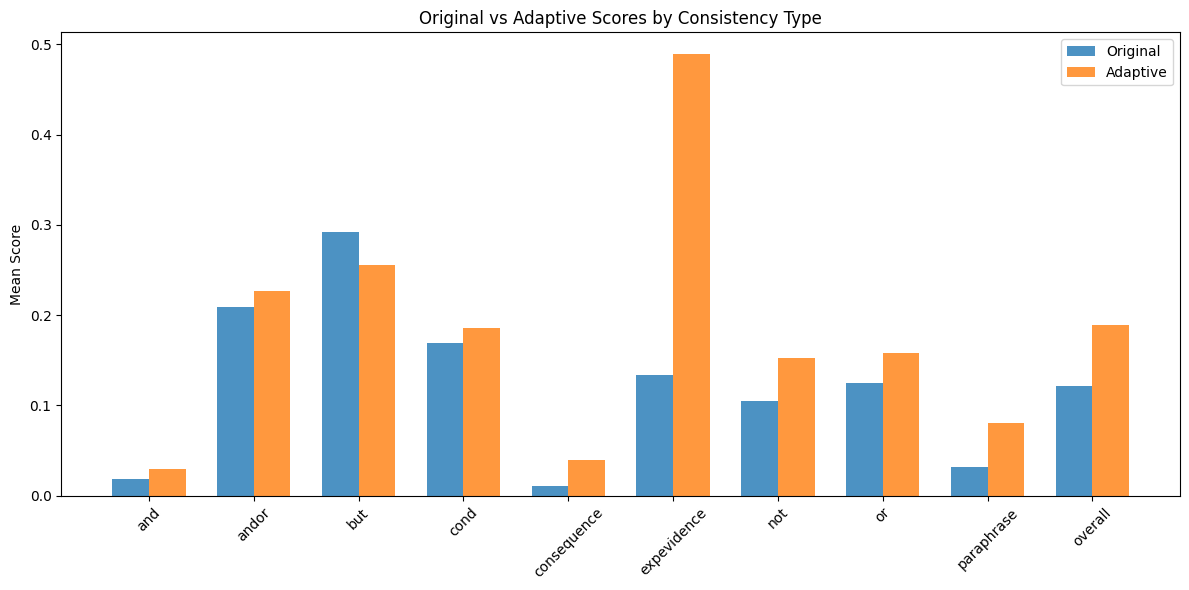

In [95]:
# Combine the two dataframes side by side
combined_stats = pd.concat([
    stats.add_suffix('_original'), 
    adaptive_stats.add_suffix('_adaptive')
], axis=1)

# Round for cleaner display
combined_stats = combined_stats.round(3)

# Add overall statistics as a new row
combined_stats.loc['overall'] = [
    overall_stats['mean'], 
    overall_stats['std'],
    adaptive_overall_stats['mean'], 
    adaptive_overall_stats['std']
]

print("\nComparison of Original vs Adaptive Statistics:")
print("============================================")
print(combined_stats)


fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(combined_stats.index))
width = 0.35

ax.bar(x - width/2, combined_stats['mean_original'], width, label='Original', alpha=0.8)
ax.bar(x + width/2, combined_stats['mean_adaptive'], width, label='Adaptive', alpha=0.8)

ax.set_ylabel('Mean Score')
ax.set_title('Original vs Adaptive Scores by Consistency Type')
ax.set_xticks(x)
ax.set_xticklabels(combined_stats.index, rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

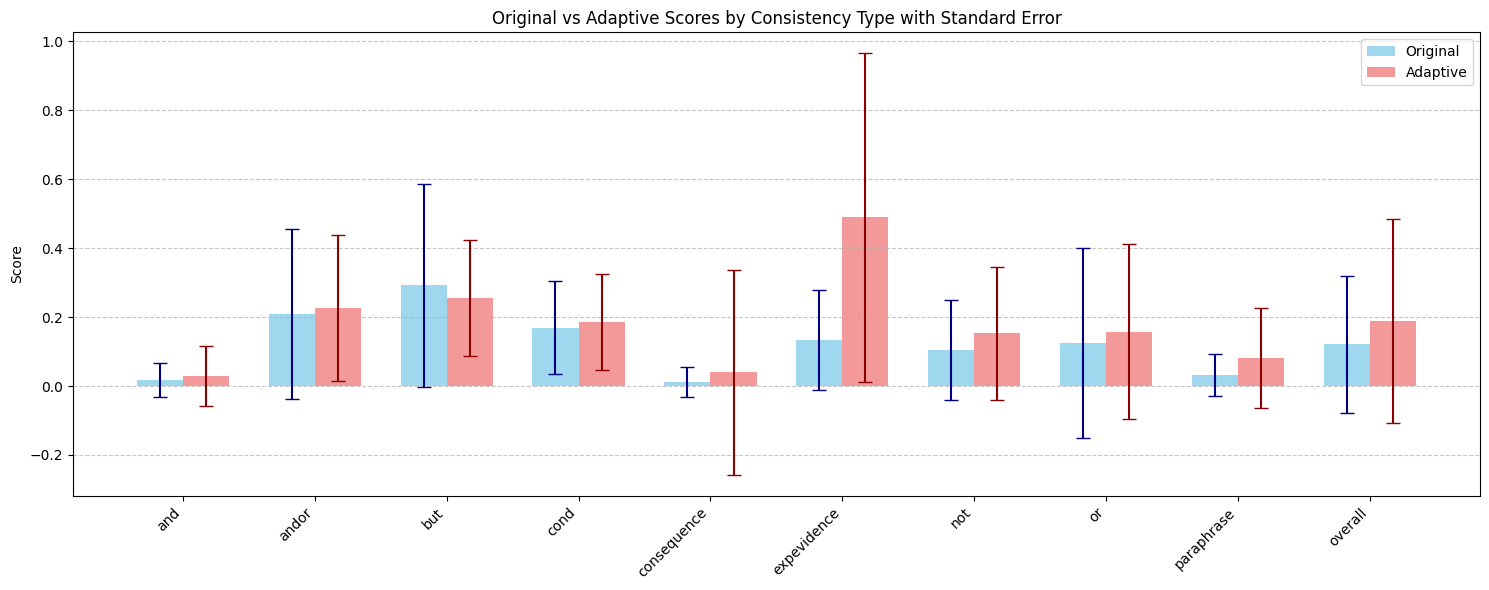

In [96]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(15, 6))

# Set up positions for bars
x = np.arange(len(combined_stats.index))
width = 0.35

# Create bars with error bars
original = ax.bar(x - width/2, combined_stats['mean_original'], width, 
                 label='Original', 
                 color='skyblue',
                 alpha=0.8)
adaptive = ax.bar(x + width/2, combined_stats['mean_adaptive'], width, 
                 label='Adaptive', 
                 color='lightcoral',
                 alpha=0.8)

# Add error bars
ax.errorbar(x - width/2, combined_stats['mean_original'], 
           yerr=combined_stats['std_original'], 
           fmt='none', color='navy', capsize=5)
ax.errorbar(x + width/2, combined_stats['mean_adaptive'], 
           yerr=combined_stats['std_adaptive'], 
           fmt='none', color='darkred', capsize=5)

# Customize the plot
ax.set_ylabel('Score')
ax.set_title('Original vs Adaptive Scores by Consistency Type with Standard Error')
ax.set_xticks(x)
ax.set_xticklabels(combined_stats.index, rotation=45, ha='right')
ax.legend()

# Add grid for better readability
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show plot
plt.show()